In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip -q install -U rfdetr==1.4.2 supervision matplotlib


import torch
print("CUDA available:", torch.cuda.is_available())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.2/163.2 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.4/217.4 kB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 110.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 887.9/887.9 MB 831.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.4/322.4 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 127.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 110.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.0/94.0 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [3]:
import os
from pathlib import Path
from rfdetr import RFDETRSmall

DATASET_PATH = Path("")

OUTPUT_PATH  = Path("")
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

EPOCHS           = 50
BATCH_SIZE       = 4
GRAD_ACCUM_STEPS = 4
LEARNING_RATE    = 1e-4
CHECKPOINT_INTERVAL = 2


RESUME_PATH = OUTPUT_PATH / "checkpoint.pth"
resume_arg  = str(RESUME_PATH) if RESUME_PATH.exists() else None


model = RFDETRSmall()

[2026-02-18 20:23:21] [INFO] rf-detr - Downloading pretrained weights for rf-detr-small.pth


rf-detr-small.pth: 100%|██████████| 368M/368M [00:04<00:00, 88.5MiB/s]
[2026-02-18 20:23:26] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-02-18 20:23:26] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-02-18 20:23:26] [INFO] rf-detr - Loading pretrain weights


In [4]:
import json
from pathlib import Path

DATASET_PATH = Path("")

annotation_file = DATASET_PATH / "train" / "_annotations.coco.json"

with open(annotation_file, "r") as f:
    coco_data = json.load(f)

categories = coco_data["categories"]

print("Number of categories:", len(categories))
print("\nCategories:\n")

for cat in categories:
    print(f"ID: {cat['id']}, Name: {cat['name']}")

Number of categories: 25

Categories:

ID: 0, Name: objects-Hardware-09aN
ID: 1, Name: Adjustable Wrench
ID: 2, Name: Allen Key
ID: 3, Name: Allen Key Set
ID: 4, Name: Bolt
ID: 5, Name: Brush
ID: 6, Name: Claw Hammer
ID: 7, Name: Cutting Pliers
ID: 8, Name: Flathead Screwdriver
ID: 9, Name: Hand Saw
ID: 10, Name: Knife
ID: 11, Name: Nail
ID: 12, Name: Needle-Nose Pliers
ID: 13, Name: Non Adjustable Wrench
ID: 14, Name: Nut
ID: 15, Name: PTFE Thread Seal Tape
ID: 16, Name: Phillips Screwdriver
ID: 17, Name: Regular Pliers
ID: 18, Name: Scissors
ID: 19, Name: Screw
ID: 20, Name: Steel Ruler
ID: 21, Name: Tape Measure
ID: 22, Name: Utility Cutter
ID: 23, Name: Vernier Calipers
ID: 24, Name: Voltage Tester


In [5]:
model.train(
    dataset_dir=str(DATASET_PATH),
    output_dir=str(OUTPUT_PATH),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    grad_accum_steps=GRAD_ACCUM_STEPS,
    lr=LEARNING_RATE,
    checkpoint_interval=CHECKPOINT_INTERVAL,
    resume=resume_arg,     # resumes from checkpoint if exists
    use_ema=True,          # enable EMA weights
    early_stopping=True,   # stop early if validation mAP doesn’t improve
    early_stopping_patience=4
)


[2026-02-18 20:23:54] [WARNING] rf-detr - Reinitializing your detection head with 25 classes.


[2026-02-18 20:23:54] [INFO] rf-detr - TensorBoard logging initialized. To monitor logs, use 'tensorboard --logdir /content/drive/.shortcut-targets-by-id/1HkLbwFyKHce1tkWekSE2XLjgiHQtwwOt/rfdetr_small_runs/exp1' and open http://localhost:6006/ in browser.
[2026-02-18 20:23:54] [INFO] rf-detr - Not using distributed mode
[2026-02-18 20:23:54] [INFO] rf-detr - git:
  unknown

[2026-02-18 20:23:54] [INFO] rf-detr - Namespace(num_classes=25, grad_accum_steps=4, print_freq=10, amp=True, lr=0.0001, lr_encoder=0.00015, batch_size=4, weight_decay=0.0001, epochs=46, lr_drop=100, clip_max_norm=0.1, lr_vit_layer_decay=0.8, lr_component_decay=0.7, do_benchmark=False, dropout=0, drop_path=0.0, drop_mode='standard', drop_schedule='constant', cutoff_epoch=0, pretrained_encoder=None, pretrain_weights='rf-detr-small.pth', pretrain_exclude_keys=None, pretrain_keys_modify_to_load=None, pretrained_distiller=None, encoder='dinov2_windowed_small', vit_encoder_num_layers=12, window_block_indexes=None, positi

[2026-02-18 20:24:20] [INFO] rf-detr - Epoch: [44]  [  0/475]  eta: 1:48:01  lr: 0.000100  class_error: 0.00  loss: 2.1789 (2.1789)  loss_ce: 0.2268 (0.2268)  loss_bbox: 0.1152 (0.1152)  loss_giou: 0.1258 (0.1258)  loss_ce_0: 0.1983 (0.1983)  loss_bbox_0: 0.0979 (0.0979)  loss_giou_0: 0.1013 (0.1013)  loss_ce_1: 0.2156 (0.2156)  loss_bbox_1: 0.1008 (0.1008)  loss_giou_1: 0.1147 (0.1147)  loss_ce_enc: 0.3707 (0.3707)  loss_bbox_enc: 0.2773 (0.2773)  loss_giou_enc: 0.2343 (0.2343)  loss_ce_unscaled: 0.2268 (0.2268)  class_error_unscaled: 0.0000 (0.0000)  loss_bbox_unscaled: 0.0230 (0.0230)  loss_giou_unscaled: 0.0629 (0.0629)  cardinality_error_unscaled: 3829.2500 (3829.2500)  loss_ce_0_unscaled: 0.1983 (0.1983)  loss_bbox_0_unscaled: 0.0196 (0.0196)  loss_giou_0_unscaled: 0.0506 (0.0506)  cardinality_error_0_unscaled: 3695.2500 (3695.2500)  loss_ce_1_unscaled: 0.2156 (0.2156)  loss_bbox_1_unscaled: 0.0202 (0.0202)  loss_giou_1_unscaled: 0.0574 (0.0574)  cardinality_error_1_unscaled: 375

[2026-02-18 20:58:08] [INFO] rf-detr - Test:  [  0/252]  eta: 0:03:08  class_error: 0.00  loss: 2.2604 (2.2604)  loss_ce: 0.2344 (0.2344)  loss_bbox: 0.0936 (0.0936)  loss_giou: 0.1323 (0.1323)  loss_ce_0: 0.2773 (0.2773)  loss_bbox_0: 0.1050 (0.1050)  loss_giou_0: 0.1372 (0.1372)  loss_ce_1: 0.2422 (0.2422)  loss_bbox_1: 0.0980 (0.0980)  loss_giou_1: 0.1321 (0.1321)  loss_ce_enc: 0.3984 (0.3984)  loss_bbox_enc: 0.1880 (0.1880)  loss_giou_enc: 0.2219 (0.2219)  loss_ce_unscaled: 0.2344 (0.2344)  class_error_unscaled: 0.0000 (0.0000)  loss_bbox_unscaled: 0.0187 (0.0187)  loss_giou_unscaled: 0.0662 (0.0662)  cardinality_error_unscaled: 291.5000 (291.5000)  loss_ce_0_unscaled: 0.2773 (0.2773)  loss_bbox_0_unscaled: 0.0210 (0.0210)  loss_giou_0_unscaled: 0.0686 (0.0686)  cardinality_error_0_unscaled: 285.2500 (285.2500)  loss_ce_1_unscaled: 0.2422 (0.2422)  loss_bbox_1_unscaled: 0.0196 (0.0196)  loss_giou_1_unscaled: 0.0660 (0.0660)  cardinality_error_1_unscaled: 290.2500 (290.2500)  loss_c

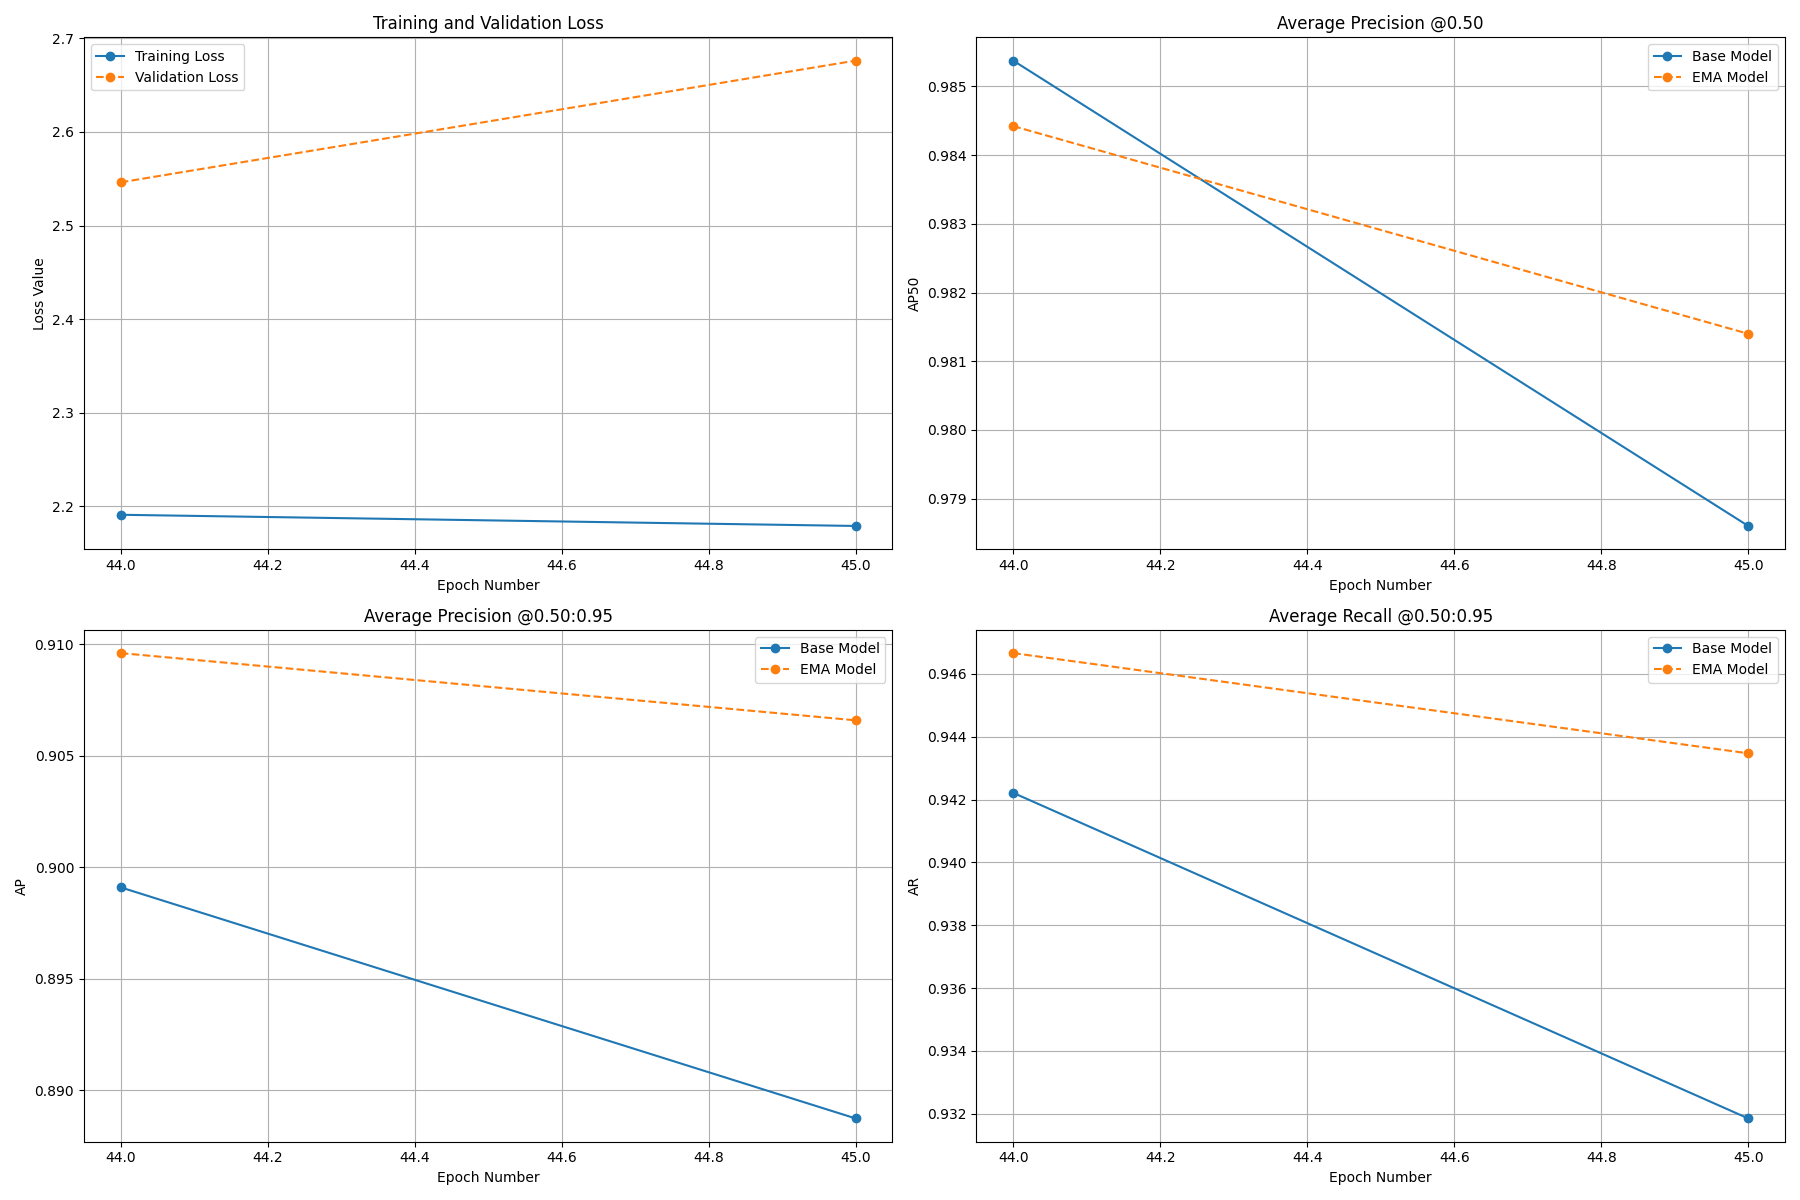

In [6]:
from PIL import Image
from IPython.display import display

metrics_plot = Image.open(OUTPUT_PATH / "metrics_plot.png")
display(metrics_plot)

In [7]:
BEST_CHECKPOINT = OUTPUT_PATH / "checkpoint_best_total.pth"
model = RFDETRSmall(pretrain_weights=str(BEST_CHECKPOINT))
model.optimize_for_inference()

[2026-02-18 21:35:44] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-02-18 21:35:44] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-02-18 21:35:44] [INFO] rf-detr - Loading pretrain weights


[2026-02-18 21:35:45] [WARNING] rf-detr - Reinitializing detection head with 24 classes based on pretrained weights, configured for 90.
`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


In [8]:
import supervision as sv
from supervision.metrics import MeanAveragePrecision
from tqdm import tqdm
from PIL import Image

def evaluate_split(model, dataset_root: Path, split_name: str):
    ds = sv.DetectionDataset.from_coco(
        images_directory_path=str(dataset_root / split_name),
        annotations_path=str(dataset_root / split_name / "_annotations.coco.json"),
    )
    preds, targets = [], []
    for path, _, ann in tqdm(ds, desc=f"Evaluating {split_name}"):
        img = Image.open(path)
        det = model.predict(img, threshold=0.0)
        preds.append(det)
        targets.append(ann)
    mAP_metric = MeanAveragePrecision()
    return mAP_metric.update(preds, targets).compute(), ds.classes, preds, targets

map_valid, classes_valid, preds_valid, targets_valid = evaluate_split(model, DATASET_PATH, "valid")
map_test,  classes_test,  preds_test,  targets_test  = evaluate_split(model, DATASET_PATH, "test")

print("Valid mAP:", map_valid)
print("Test mAP :", map_test)


Evaluating test: 100%|██████████| 1004/1004 [00:41<00:00, 24.27it/s]


Valid mAP: Average Precision (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.910
Average Precision (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.984
Average Precision (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.976
Average Precision (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.700
Average Precision (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.645
Average Precision (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.919
Test mAP : Average Precision (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.913
Average Precision (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.988
Average Precision (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.971
Average Precision (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
Average Precision (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.740
Average Precision (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.921


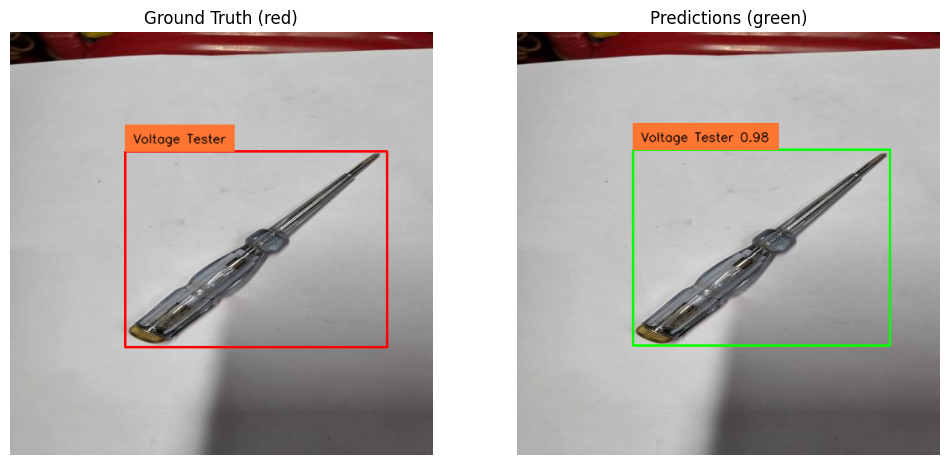

In [10]:
import supervision as sv
from PIL import Image

def safe_name(cid, classes):
    cid = int(cid)
    if 0 <= cid < len(classes):
        return classes[cid]
    return f"UNK({cid})"


sample_ds = sv.DetectionDataset.from_coco(
    images_directory_path=str(DATASET_PATH / "test"),
    annotations_path=str(DATASET_PATH / "test" / "_annotations.coco.json"),
)

path, _, ann = sample_ds[0]
img = Image.open(path).convert("RGB")

detections = model.predict(img, threshold=0.5)


gt_labels = [safe_name(cid, sample_ds.classes) for cid in ann.class_id]

pred_conf = getattr(detections, "confidence", None)
if pred_conf is None:
    pred_labels = [safe_name(cid, sample_ds.classes) for cid in detections.class_id]
else:
    pred_labels = [
        f"{safe_name(cid, sample_ds.classes)} {float(conf):.2f}"
        for cid, conf in zip(detections.class_id, pred_conf)
    ]


try:
    gt_box_annotator = sv.BoxAnnotator(color=sv.Color.RED)
    pr_box_annotator = sv.BoxAnnotator(color=sv.Color.GREEN)
except Exception:
    gt_box_annotator = sv.BoxAnnotator()
    pr_box_annotator = sv.BoxAnnotator()

try:
    label_annotator = sv.LabelAnnotator(text_color=sv.Color.BLACK)
except Exception:
    label_annotator = sv.LabelAnnotator()


gt_img = gt_box_annotator.annotate(img.copy(), ann)
gt_img = label_annotator.annotate(gt_img, ann, gt_labels)


pred_img = pr_box_annotator.annotate(img.copy(), detections)
pred_img = label_annotator.annotate(pred_img, detections, pred_labels)

sv.plot_images_grid([gt_img, pred_img], grid_size=(1, 2), titles=["Ground Truth (red)", "Predictions (green)"])


In [14]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import matplotlib as mpl
import supervision as sv
from PIL import Image



N_IMAGES = 12
GRID_COLS = 4
PRED_THRESHOLD = 0.5
SAVE_DPI = 600
SEED = 43
OUT_NAME = "qualitative_predictions_grid"


OUTPUT_PATH = Path(OUTPUT_PATH)
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)


def safe_name(cid, classes):
    cid = int(cid)
    if 0 <= cid < len(classes):
        return classes[cid]
    return f"UNK({cid})"


def build_predictions_grid(
    dataset_path: Path,
    split: str = "test",
    n_images: int = 12,
    grid_cols: int = 4,
    pred_threshold: float = 0.5,
    seed: int = 42,
    save_png: Path | None = None,
    save_pdf: Path | None = None,
):

    old_rc = mpl.rcParams.copy()
    mpl.rcParams.update({
        "figure.dpi": 200,
        "savefig.dpi": SAVE_DPI,
        "font.size": 16,
        "axes.titlesize": 18,
        "axes.labelsize": 16,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "figure.titlesize": 22,
    })

    try:

        ds = sv.DetectionDataset.from_coco(
            images_directory_path=str(dataset_path / split),
            annotations_path=str(dataset_path / split / "_annotations.coco.json"),
        )

        random.seed(seed)
        indices = list(range(len(ds)))
        random.shuffle(indices)
        indices = indices[: min(n_images, len(indices))]


        try:
            box_annotator = sv.BoxAnnotator(thickness=3)
        except TypeError:
            box_annotator = sv.BoxAnnotator()

        try:
            label_annotator = sv.LabelAnnotator(text_scale=1.2, text_thickness=2)
        except TypeError:
            label_annotator = sv.LabelAnnotator()

        annotated_images = []

        for idx in indices:
            path, _, ann = ds[idx]
            img = Image.open(path).convert("RGB")

            detections = model.predict(img, threshold=pred_threshold)


            pred_conf = getattr(detections, "confidence", None)
            if pred_conf is None:
                pred_labels = [safe_name(cid, ds.classes) for cid in detections.class_id]
            else:
                pred_labels = [
                    f"{safe_name(cid, ds.classes)} {float(conf):.2f}"
                    for cid, conf in zip(detections.class_id, pred_conf)
                ]


            canvas = img.copy()
            canvas = box_annotator.annotate(canvas, detections)
            canvas = label_annotator.annotate(canvas, detections, pred_labels)

            annotated_images.append(canvas)


        rows = (len(annotated_images) + grid_cols - 1) // grid_cols


        fig_w = grid_cols * 6.0
        fig_h = rows * 4.8

        fig, axes = plt.subplots(rows, grid_cols, figsize=(fig_w, fig_h))
        if rows == 1 and grid_cols == 1:
            axes = [[axes]]
        elif rows == 1:
            axes = [axes]
        elif grid_cols == 1:
            axes = [[ax] for ax in axes]


        for i in range(rows * grid_cols):
            r = i // grid_cols
            c = i % grid_cols
            ax = axes[r][c]
            ax.axis("off")

            if i < len(annotated_images):
                ax.imshow(annotated_images[i])
            else:
                ax.set_visible(False)

        fig.suptitle("Qualitative Predictions", y=0.995)
        plt.tight_layout()


        if save_png is not None:
            fig.savefig(save_png, dpi=SAVE_DPI, bbox_inches="tight", pad_inches=0.15)

        if save_pdf is not None:

            fig.savefig(save_pdf, bbox_inches="tight", pad_inches=0.15)

        plt.close(fig)

        return annotated_images

    finally:
        mpl.rcParams.update(old_rc)


png_path = OUTPUT_PATH / f"{OUT_NAME}.png"
pdf_path = OUTPUT_PATH / f"{OUT_NAME}.pdf"

build_predictions_grid(
    dataset_path=DATASET_PATH,
    split="test",
    n_images=N_IMAGES,
    grid_cols=GRID_COLS,
    pred_threshold=PRED_THRESHOLD,
    seed=SEED,
    save_png=png_path,
    save_pdf=pdf_path,
)

print("Saved:", png_path)
print("Saved:", pdf_path)

Saved: /content/drive/MyDrive/rfdetr_small_runs/exp1/qualitative_predictions_grid.png
Saved: /content/drive/MyDrive/rfdetr_small_runs/exp1/qualitative_predictions_grid.pdf


# Larger Confusion matrix

In [15]:
import matplotlib.pyplot as plt
import matplotlib as mpl

import supervision as sv
try:
    ConfusionMatrix = sv.ConfusionMatrix
except AttributeError:
    try:
        from supervision.metrics.detection import ConfusionMatrix
    except Exception:
        from supervision.metrics import ConfusionMatrix


def plot_confusion(
    preds,
    targets,
    class_names,
    split_name,
    conf_thr=0.3,
    iou_thr=0.5,
    include_fp_fn=True,
):

    import math


    MAX_PIXELS = 20_000_000


    TARGET_SAVE_DPI = 600


    MAX_FIG_INCH = 30

    def safe_dpi(fig_w_in, fig_h_in, target_dpi=TARGET_SAVE_DPI, max_pixels=MAX_PIXELS):

        if fig_w_in <= 0 or fig_h_in <= 0:
            return target_dpi
        dpi_cap = math.sqrt(max_pixels / (fig_w_in * fig_h_in))

        return int(max(120, min(target_dpi, dpi_cap)))

    _old_rc = mpl.rcParams.copy()
    mpl.rcParams.update({
        "figure.dpi": 200,
        "savefig.dpi": 600,
        "font.size": 26,
        "axes.titlesize": 28,
        "axes.labelsize": 28,
        "xtick.labelsize": 28,
        "ytick.labelsize": 28,
        "legend.fontsize": 26,
        "figure.titlesize": 30,
    })

    try:
        cm = ConfusionMatrix.from_detections(
            predictions=preds,
            targets=targets,
            classes=class_names,
            conf_threshold=conf_thr,
            iou_threshold=iou_thr
        )

        n = len(class_names)

        fig_w = min(60, max(18, 1.6 * n))
        fig_h = min(55, max(16, 1.3 * n))

        fig_w = min(fig_w, MAX_FIG_INCH)
        fig_h = min(fig_h, MAX_FIG_INCH)

        if include_fp_fn:
            fig = cm.plot(fig_size=(fig_w, fig_h))
        else:
            import numpy as np

            M = None
            for attr in ("matrix", "confusion_matrix", "cm"):
                if hasattr(cm, attr):
                    M = getattr(cm, attr)
                    break

            if M is None:
                fig = cm.plot(fig_size=(fig_w, fig_h))
            else:
                M = np.asarray(M)
                M = M[:-1, :-1]

                fig, ax = plt.subplots(figsize=(fig_w, fig_h))
                im = ax.imshow(M)
                ax.set_title(f"Confusion Matrix ({split_name})")
                ax.set_xlabel("Predicted")
                ax.set_ylabel("True")

                ax.set_xticks(range(n))
                ax.set_yticks(range(n))
                ax.set_xticklabels(class_names, rotation=90)
                ax.set_yticklabels(class_names)

                for i in range(n):
                    for j in range(n):
                        v = int(M[i, j])
                        if v != 0:
                            ax.text(j, i, str(v), ha="center", va="center", fontsize=16)

                fig.colorbar(im, ax=ax)

        ax = fig.axes[0]

        ax.tick_params(axis="x", labelsize=30)
        ax.tick_params(axis="y", labelsize=30)

        for lab in ax.get_xticklabels():
            lab.set_rotation(90)
            lab.set_ha("center")
            lab.set_va("top")

        ax.set_xlabel("Predicted", fontsize=30)
        ax.set_ylabel("True", fontsize=30)
        ax.set_title(f"Confusion Matrix ({split_name})", fontsize=30)

        if len(fig.axes) > 1:
            cax = fig.axes[-1]
            try:
                cax.tick_params(labelsize=30)
            except Exception:
                pass

        fig.subplots_adjust(left=0.30, bottom=0.35, right=0.98, top=0.95)


        dpi_to_use = safe_dpi(fig_w, fig_h)

        path = OUTPUT_PATH / f"confusion_matrix_{split_name}.png"

        fig.savefig(path, dpi=dpi_to_use, bbox_inches="tight", pad_inches=0.25)

        plt.close(fig)
        return path

    finally:
        mpl.rcParams.update(_old_rc)


print("Confusion matrix (valid):", plot_confusion(preds_valid, targets_valid, classes_valid, "valid", include_fp_fn=True))
print("Confusion matrix (test) :", plot_confusion(preds_test,  targets_test,  classes_test,  "test",  include_fp_fn=True))


Confusion matrix (valid): /content/drive/MyDrive/rfdetr_small_runs/exp1/confusion_matrix_valid.png
Confusion matrix (test) : /content/drive/MyDrive/rfdetr_small_runs/exp1/confusion_matrix_test.png
